# Ejecución presupuestal - Proyectos por gobiernos regionales - Provinciales - Distritales - Mes de julio 2026

### Objetivo

- Determinar que gobiernos regionales del Perú esta ejecutando mejor su presupuesto de proyectos a la fecha de julio 2026.
- Analizar que provincias de la región junín esta ejecutando mejor su presupuesto de proyectos a la fecha de julio 2026.
- Analizar que distritos de la Provincia de Huancayo esta ejecutando mejor su presupuesto de proyectos a la fecha de julio 2026.

### Fuente de datos

- [Presupuesto publico 2026](https://datosabiertos.mef.gob.pe/dataset/presupuesto-y-ejecucion-de-gasto)

In [1]:
# Librearias
import os

import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import requests


# plt.style.use('')
plt.rcParams.update({
    'figure.figsize'    :   (12,6)      ,
    # 'axes.facecolor'    :   '#0d1117'   ,
    # 'figure.facecolor'  :   '#30363d'   ,
    'grid.linestyle'    :   '--'        ,
    'grid.alpha'        :   0.5         ,
    'font.size'         :   10          ,
})

In [2]:
# URL = "https://api.datosabiertos.mef.gob.pe/DatosAbiertos/v1/datastore_search"

# params = {
#     "resource_id": "d45f660d-6d14-438e-9d91-300084c9b85f",
#     "limit": 1000,
# }

# response = requests.get(URL, params=params)

# print(response.status_code)

# data = response.json()

# # miramos las claves principales
# print(data.keys()) # dict_keys(['sucess', 'result', 'records', 'next', 'help'])
# print("Registros:", len(data.get("records", [])))
# print("Total:", data.get("result", {}).get("include_total"))
# print("Next:", data.get("next"))

In [3]:
# # Comprobamos limites maximos
# for limit in [1000, 5000, 10000, 50000, 100000]:
    
#     params = {
#         "resource_id": "d45f660d-6d14-438e-9d91-300084c9b85f",
#         "limit": limit, # Cuantos registros quiero por peticion
#         "offset": 0 # desde donde que pagina empezar
#     }

#     response = requests.get(URL, params=params)
#     data = response.json()

#     print(
#         f"Solicitado: {limit:,} | "
#         f"Devuelto: {len(data.get('records', [])):,} | "
#         f"HTTP: {response.status_code}"
#     )

In [4]:
# params = {
#     "resource_id": "d45f660d-6d14-438e-9d91-300084c9b85f",
#     "limit": 32_000,
#     "offset": 0
# }

# response = requests.get(URL, params=params)
# data = response.json()

# print("HTTP:", response.status_code)
# print("Solicitados:", 32_000)
# print("Devueltos:", len(data["records"]))
# print("Total:", data["result"]["include_total"])
# print("Next:", data.get("next"))

In [5]:
# LIMIT = 32_000

# for offset in [0, 32_000, 64_000]:

#     params = {
#         "resource_id": "d45f660d-6d14-438e-9d91-300084c9b85f",
#         "limit": LIMIT,
#         "offset": offset
#     }

#     response = requests.get(URL, params=params)

#     response.raise_for_status()

#     data = response.json()

#     records = data["records"]

#     print(
#         f"Offset: {offset:,} | "
#         f"Registros: {len(records):,}"
#     )

In [6]:
# URL = "https://api.datosabiertos.mef.gob.pe/DatosAbiertos/v1/datastore_search"

# RESOURCE_ID = "d45f660d-6d14-438e-9d91-300084c9b85f"
# LIMIT = 32_000

# todos_los_records = []

# offset = 0

# while True:

#     params = {
#         "resource_id": RESOURCE_ID,
#         "limit": LIMIT,
#         "offset": offset
#     }

#     response = requests.get(URL, params=params)
#     response.raise_for_status()

#     data = response.json()

#     records = data["records"]

#     todos_los_records.extend(records)

#     print(
#         f"Offset: {offset:,} | "
#         f"Descargados: {len(todos_los_records):,}"
#     )

#     # Si llegaron menos registros que LIMIT,
#     # significa que llegamos al final.
#     if len(records) < LIMIT:
#         break

#     offset += LIMIT


# print(f"\nTotal descargado: {len(todos_los_records):,}")

# df = pl.DataFrame(todos_los_records)

# print(f"Filas: {df.height:,}")
# print(f"Columnas: {df.width}")

In [7]:
# import requests
# import polars as pl
# import pyarrow.parquet as pq


# URL = "https://api.datosabiertos.mef.gob.pe/DatosAbiertos/v1/datastore_search"

# RESOURCE_ID = "d45f660d-6d14-438e-9d91-300084c9b85f"

# LIMIT = 32_000

# OUTPUT = "mef_2026.parquet"


# writer = None
# columnas = None

# offset = 0
# pagina = 1


# while True:

#     params = {
#         "resource_id": RESOURCE_ID,
#         "limit": LIMIT,
#         "offset": offset
#     }

#     response = requests.get(URL, params=params)
#     response.raise_for_status()

#     data = response.json()
#     records = data["records"]

#     if not records:
#         break

#     # API → Polars
#     df = pl.DataFrame(records)

#     # Guardamos el orden de columnas de la primera página
#     if columnas is None:
#         columnas = df.columns

#     # Forzamos el mismo orden en todas las páginas
#     df = df.select(columnas)

#     print(
#         f"Página {pagina}/{MAX_PAGINAS} | "
#         f"Offset: {offset:,} | "
#         f"Registros: {df.height:,}"
#     )

#     # Polars → Arrow
#     table = df.to_arrow()

#     # Crear ParquetWriter solamente una vez
#     if writer is None:

#         writer = pq.ParquetWriter(
#             OUTPUT,
#             table.schema,
#             compression="zstd"
#         )

#     # Agregar página al Parquet
#     writer.write_table(table)

#     # Liberar memoria
#     del table
#     del df
#     del records
#     del data

#     offset += LIMIT
#     pagina += 1


# # Cerrar el archivo
# if writer is not None:
#     writer.close()


# print()
# print("Descarga de prueba completada.")

In [8]:
# import polars as pl

# df = pl.read_parquet("mef_2026.parquet")

# print("Filas:", df.height)
# print("Columnas:", df.width)

# print("\nColumnas:")
# print(df.columns)

In [9]:
# df = pl.read_parquet("mef_2026.parquet")

# columnas_numericas = [
#     "ANO_EJE",
#     "MES_EJE",
#     "MONTO_PIA",
#     "MONTO_PIM",
#     "MONTO_CERTIFICADO",
#     "MONTO_COMPROMETIDO",
#     "MONTO_COMPROMETIDO_ANUAL",
#     "MONTO_DEVENGADO",
#     "MONTO_GIRADO",
# ]

# for columna in columnas_numericas:
#     print(f"\n{'=' * 60}")
#     print(columna)
#     print(df.select(pl.col(columna).unique().head(10)))

In [10]:

# df = pl.read_parquet("mef_2026.parquet")

# columnas_int = [
#     "ANO_EJE",
#     "MES_EJE",
# ]

# columnas_float = [
#     "MONTO_PIA",
#     "MONTO_PIM",
#     "MONTO_CERTIFICADO",
#     "MONTO_COMPROMETIDO",
#     "MONTO_COMPROMETIDO_ANUAL",
#     "MONTO_DEVENGADO",
#     "MONTO_GIRADO",
# ]

# df_test = df.select(
#     [
#         pl.col(c).cast(pl.Int64).alias(c)
#         for c in columnas_int
#     ]
#     +
#     [
#         pl.col(c).cast(pl.Float64).alias(c)
#         for c in columnas_float
#     ]
# )

# print(df_test.schema)
# print()
# print(df_test.head())

In [11]:
# df_clean = df.with_columns(
#     [
#         pl.col(c).cast(pl.Int64)
#         for c in columnas_int
#     ]
#     +
#     [
#         pl.col(c).cast(pl.Float64)
#         for c in columnas_float
#     ]
# )

# df_clean.write_parquet(
#     "mef_2026_clean.parquet",
#     compression="zstd"
# )

# print("Archivo Silver creado correctamente.")
# print(f"Filas: {df_clean.height:,}")
# print(f"Columnas: {df_clean.width}")

# print("\nSchema:")
# print(df_clean.schema)

In [12]:
# df = pl.read_parquet("mef_2026.parquet")

# print("Filas:", df.height)
# print("Columnas:", df.width)

# print("\nSchema:")
# print(df.schema)

In [13]:
df = pd.read_csv('../data/raw/2026-Gasto-Mensual.csv',
                dtype = {
                    'SECTOR'        :   'string',
                    'PLIEGO'        :   'string',
                    'TIPO_RECURSO'  :   'string'
                })
df.head(2)

,ANO_EJE,MES_EJE,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,SECTOR,SECTOR_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA,...,ESPECIFICA_NOMBRE,ESPECIFICA_DET,ESPECIFICA_DET_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_CERTIFICADO,MONTO_COMPROMETIDO_ANUAL,MONTO_COMPROMETIDO,MONTO_DEVENGADO,MONTO_GIRADO
0,2026,8,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL DEL DEPARTAMENTO DE AMAZONAS,721,1,...,LOCACIÓN DE SERVICIOS REALIZADOS POR PERSONA N...,1,LOCACIÓN DE SERVICIOS REALIZADOS POR PERSONA N...,0,0,2500.0,2500.0,0.00,0.00,0.00
1,2026,8,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL DEL DEPARTAMENTO DE AMAZONAS,725,400,...,ADQUISICION DE EQUIPOS INFORMATICOS Y DE COMUN...,1,EQUIPOS COMPUTACIONALES Y PERIFERICOS,0,0,0.0,0.0,3160.68,8426.23,8426.23


In [14]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7689615 entries, 0 to 7689614
Data columns (total 63 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   ANO_EJE                        int64  
 1   MES_EJE                        int64  
 2   NIVEL_GOBIERNO                 str    
 3   NIVEL_GOBIERNO_NOMBRE          str    
 4   SECTOR                         string 
 5   SECTOR_NOMBRE                  str    
 6   PLIEGO                         string 
 7   PLIEGO_NOMBRE                  str    
 8   SEC_EJEC                       int64  
 9   EJECUTORA                      int64  
 10  EJECUTORA_NOMBRE               str    
 11  DEPARTAMENTO_EJECUTORA         int64  
 12  DEPARTAMENTO_EJECUTORA_NOMBRE  str    
 13  PROVINCIA_EJECUTORA            int64  
 14  PROVINCIA_EJECUTORA_NOMBRE     str    
 15  DISTRITO_EJECUTORA             int64  
 16  DISTRITO_EJECUTORA_NOMBRE      str    
 17  SEC_FUNC                       int64  
 18  PROGRAMA_PPTO

In [15]:
print(df.isnull().sum())

ANO_EJE                     0
MES_EJE                     0
NIVEL_GOBIERNO              0
NIVEL_GOBIERNO_NOMBRE       0
SECTOR                      0
                           ..
MONTO_CERTIFICADO           0
MONTO_COMPROMETIDO_ANUAL    0
MONTO_COMPROMETIDO          0
MONTO_DEVENGADO             0
MONTO_GIRADO                0
Length: 63, dtype: int64


In [16]:
# COMPRENSIÓN DE LAS VARIABLES

# print(df.NIVEL_GOBIERNO_NOMBRE.unique())
# print(df.SEC_EJEC.unique())
# print(df.EJECUTORA.unique())
# print(df.EJECUTORA_NOMBRE.unique())
# print(df.DEPARTAMENTO_EJECUTORA_NOMBRE.unique())
# print(df.PROVINCIA_EJECUTORA_NOMBRE.unique())
# print(df.DISTRITO_EJECUTORA_NOMBRE.unique())
# print(df.PROGRAMA_PPTO_NOMBRE.unique())
# print(df.TIPO_ACT_PROY_NOMBRE.unique())
# print(df.PRODUCTO_PROYECTO_NOMBRE.unique())
# print(df.GENERICA_NOMBRE.unique())
# print(df.SUBGENERICA_NOMBRE.unique())
# print(df.ESPECIFICA_NOMBRE.unique())
# print(df.FUNCION_NOMBRE.unique())
# print(df.PROGRAMA_PPTO_NOMBRE.unique())
# print(df.CATEGORIA_GASTO_NOMBRE.unique())
# print(df.TIPO_ACT_PROY_NOMBRE.unique())
# print(df.GENERICA_NOMBRE.unique())


In [17]:
df[['MONTO_PIA', 'MONTO_PIM', 'MONTO_CERTIFICADO', 'MONTO_COMPROMETIDO_ANUAL', 'MONTO_COMPROMETIDO', 'MONTO_DEVENGADO', 'MONTO_GIRADO']].describe()

,MONTO_PIA,MONTO_PIM,MONTO_CERTIFICADO,MONTO_COMPROMETIDO_ANUAL,MONTO_COMPROMETIDO,MONTO_DEVENGADO,MONTO_GIRADO
count,7.689615e+06,7.689615e+06,7.689615e+06,7.689615e+06,7.689615e+06,7.689615e+06,7.689615e+06
mean,3.349474e+04,3.729521e+04,3.294292e+04,3.036768e+04,2.456908e+04,2.272841e+04,2.228742e+04
std,5.147751e+06,5.079756e+06,5.018697e+06,5.002588e+06,3.329093e+06,3.360266e+06,3.331796e+06
min,0.000000e+00,-8.248440e+05,-1.140409e+09,-1.000462e+09,0.000000e+00,-8.937874e+07,-1.588818e+09
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,6.000000e+02,7.800000e+02,2.389230e+03,2.412300e+03,2.285500e+03
max,1.078797e+10,1.078797e+10,1.078790e+10,1.078790e+10,6.221093e+09,6.273908e+09,6.273908e+09


In [18]:
df[df['MONTO_PIM'] == -1.165660e+05]

,ANO_EJE,MES_EJE,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,SECTOR,SECTOR_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA,...,ESPECIFICA_NOMBRE,ESPECIFICA_DET,ESPECIFICA_DET_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_CERTIFICADO,MONTO_COMPROMETIDO_ANUAL,MONTO_COMPROMETIDO,MONTO_DEVENGADO,MONTO_GIRADO
4990104,2026,0,M,GOBIERNOS LOCALES,,,,,300041,10402,...,SERVICIOS DE CONSULTORIAS Y SIMILARES DESARROL...,99,OTROS SERVICIOS SIMILARES,3500,-116566,0.0,0.0,0.0,0.0,0.0


In [19]:
df[df["MES_EJE"] == 0][
    ["MONTO_PIA", "MONTO_PIM", "MONTO_DEVENGADO"]
].describe()

,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO
count,1.687689e+06,1.687689e+06,1687689.0
mean,1.526120e+05,1.699281e+05,0.0
std,1.098730e+07,1.084195e+07,0.0
min,0.000000e+00,-8.248440e+05,0.0
25%,0.000000e+00,5.000000e+02,0.0
50%,8.400000e+02,4.000000e+03,0.0
75%,1.001200e+04,2.644300e+04,0.0
max,1.078797e+10,1.078797e+10,0.0


In [20]:
df[df["MES_EJE"] == 0]["NIVEL_GOBIERNO_NOMBRE"].value_counts()

NIVEL_GOBIERNO_NOMBRE
GOBIERNOS LOCALES       920318
GOBIERNOS REGIONALES    399276
GOBIERNO NACIONAL       368095
Name: count, dtype: int64

In [21]:
df['NIVEL_GOBIERNO_NOMBRE'].value_counts()

NIVEL_GOBIERNO_NOMBRE
GOBIERNOS LOCALES       4094928
GOBIERNOS REGIONALES    1804835
GOBIERNO NACIONAL       1789852
Name: count, dtype: int64

In [22]:
df['TIPO_ACT_PROY_NOMBRE'].value_counts(dropna=False)

TIPO_ACT_PROY_NOMBRE
ACTIVIDAD    6879582
PROYECTO      810033
Name: count, dtype: int64

Filtramos por GOBIERNOS LOCALES, PROYECTO Y GASTO CAPITAL, para identificar las inversiones públicas.

In [23]:
proyectos_locales = df[(df['NIVEL_GOBIERNO_NOMBRE'] == 'GOBIERNOS LOCALES') &
                (df['TIPO_ACT_PROY_NOMBRE'] == 'PROYECTO') & 
                (df['CATEGORIA_GASTO_NOMBRE'] == 'GASTO DE CAPITAL')]

In [24]:
num_proyectos = (proyectos_locales
                .groupby(['DEPARTAMENTO_EJECUTORA_NOMBRE','PROVINCIA_EJECUTORA_NOMBRE', 'DISTRITO_EJECUTORA_NOMBRE','FUNCION_NOMBRE', 'PRODUCTO_PROYECTO_NOMBRE'])['PRODUCTO_PROYECTO']
                .nunique()
                .reset_index()
                .sort_values(by=['DEPARTAMENTO_EJECUTORA_NOMBRE','PRODUCTO_PROYECTO'], ascending=False))


num_proyectos[num_proyectos['DISTRITO_EJECUTORA_NOMBRE'] == 'HUANCAYO']

,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA_NOMBRE,DISTRITO_EJECUTORA_NOMBRE,FUNCION_NOMBRE,PRODUCTO_PROYECTO_NOMBRE,PRODUCTO_PROYECTO
28674,JUNIN,HUANCAYO,HUANCAYO,AMBIENTE,CREACION DEL PARQUE ZONAL COTO COTO DISTRITO D...,1
28675,JUNIN,HUANCAYO,HUANCAYO,AMBIENTE,ESTUDIOS DE PRE-INVERSION,1
28676,JUNIN,HUANCAYO,HUANCAYO,AMBIENTE,MEJORAMIENTO DEL SERVICIOS DE ESPACIOS PUBLICO...,1
28677,JUNIN,HUANCAYO,HUANCAYO,CULTURA Y DEPORTE,CREACION DEL CENTRO RECREACIONAL POLIDEPORTIVO...,1
28678,JUNIN,HUANCAYO,HUANCAYO,CULTURA Y DEPORTE,CREACION DEL SERVICIO DE PRACTICA DEPORTIVA Y/...,1
...,...,...,...,...,...,...
28752,JUNIN,HUANCAYO,HUANCAYO,VIVIENDA Y DESARROLLO URBANO,MEJORAMIENTO DE LOS SERVICIOS DE ESPACIOS PUBL...,1
28753,JUNIN,HUANCAYO,HUANCAYO,VIVIENDA Y DESARROLLO URBANO,MEJORAMIENTO DE LOS SERVICIOS PUBLICOS DE INTE...,1
28754,JUNIN,HUANCAYO,HUANCAYO,VIVIENDA Y DESARROLLO URBANO,MEJORAMIENTO DEL SERVICIOS DE ESPACIOS PUBLICO...,1
28755,JUNIN,HUANCAYO,HUANCAYO,VIVIENDA Y DESARROLLO URBANO,"MEJORAMIENTO, AMPLIACION DEL COMPLEJO DEPORTIV...",1


In [25]:
proyectos_locales.groupby('FUNCION_NOMBRE')['PRODUCTO_PROYECTO'].nunique().sort_values(ascending=False)

FUNCION_NOMBRE
TRANSPORTE                                         11254
SANEAMIENTO                                         5508
CULTURA Y DEPORTE                                   5415
AGROPECUARIA                                        4369
EDUCACION                                           4309
PLANEAMIENTO, GESTION Y RESERVA DE CONTINGENCIA     3921
VIVIENDA Y DESARROLLO URBANO                        3186
ORDEN PUBLICO Y SEGURIDAD                           1158
AMBIENTE                                            1054
SALUD                                                988
ENERGIA                                              668
PROTECCION SOCIAL                                    521
TURISMO                                              390
COMERCIO                                             294
INDUSTRIA                                            288
COMUNICACIONES                                        83
PESCA                                                 41
TRABAJO         

### Porcentaje de ejecución de proyectos publicos de la provicina de Huancayo y sus distritos


In [26]:
# PROYECTOS HUANCAYO PROVICIA Y SUS DISTRITOS MUNICIPALES
hyo_provincia = (proyectos_locales
        .groupby(['DEPARTAMENTO_EJECUTORA_NOMBRE','PROVINCIA_EJECUTORA_NOMBRE', 'EJECUTORA_NOMBRE'])
                [['MONTO_PIA','MONTO_PIM', 'MONTO_DEVENGADO']]
        .sum()
        .reset_index()
        .sort_values('MONTO_PIM', ascending=False))

hyo_provincia['EJECUCION_%'] = (hyo_provincia['MONTO_DEVENGADO'] / hyo_provincia['MONTO_PIM'])  * 100

hyo_provincia = (hyo_provincia[(hyo_provincia['DEPARTAMENTO_EJECUTORA_NOMBRE'] == 'JUNIN') & 
                (hyo_provincia['PROVINCIA_EJECUTORA_NOMBRE'] == 'HUANCAYO')]
                .sort_values('EJECUCION_%', ascending=False))

hyo_provincia.to_csv('hyo_provincia.csv', index=False)

hyo_provincia

,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA_NOMBRE,EJECUTORA_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO,EJECUCION_%
1077,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE COLCA,998679,1195230,1070079.36,89.529158
1071,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE CARHUACALLANGA,593885,2504679,1960296.55,78.265381
1088,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE PUCARA,1571933,7410848,5189021.98,70.019274
1075,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE CHONGOS ALTO,556732,6389426,4084922.08,63.932536
1093,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE SANTO DOMINGO DE AC...,2741459,6045623,3130339.96,51.778617
1090,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE QUILCAS,393492,4094219,1947739.43,47.572918
1079,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE EL TAMBO,9918676,30239177,13538025.10,44.769820
1084,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE HUAYUCACHI,11262017,17807841,7895257.65,44.335850
1085,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE INGENIO,1271998,3017993,1213293.50,40.201998
1094,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE SAPALLANGA,2637496,12840693,5017557.23,39.075440


In [27]:
import plotly.express as px

fig = px.bar(
    hyo_provincia,
    x = "EJECUCION_%",
    y = "EJECUTORA_NOMBRE",
    # title="Presupuesto ejecutado por distrito",

    text = "EJECUCION_%",
    # text_auto=".2f",
    # #hover_data = ["MONTO_DEVENGADO", "EJECUCION_%"],
    # labels = {
    #     "EJECUCION_%": "PORCENTAJE EJECUTADO",
    #     "EJECUTORA_NOMBRE":"MUNICIPALIDAD"
    # },
    # color_continuous_scale="Viridis"

)

fig.update_layout(
    title="PORCENTAJE DE EJECUCIÓN POR DISTRITO" ,title_font_size=20,
    template="plotly_dark"
)

fig.update_traces(
    textposition = "outside",
    hovertemplate="%{y}: %{x:.1f}%",
    texttemplate="%{text:.1f}",

    marker_line_width=1

)

fig.update_xaxes(
    title=" ",
    ticksuffix="%"
)

fig.update_yaxes(
    title = " "
)

fig.show()

In [28]:
presupuesto = (proyectos_locales[proyectos_locales['MES_EJE'] == 0]
                .groupby([
                        'ANO_EJE',
                        'DEPARTAMENTO_EJECUTORA_NOMBRE',
                        'PROVINCIA_EJECUTORA_NOMBRE', 
                        'DISTRITO_EJECUTORA_NOMBRE'])
                [['MONTO_PIA','MONTO_PIM']]
                .sum()
                .reset_index())
presupuesto.head()

presupuesto.to_parquet('../data/processed/presupuesto.parquet', index=False)

In [29]:
presupuesto[presupuesto['DISTRITO_EJECUTORA_NOMBRE'] == 'EL TAMBO']

,ANO_EJE,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA_NOMBRE,DISTRITO_EJECUTORA_NOMBRE,MONTO_PIA,MONTO_PIM
1078,2026,JUNIN,HUANCAYO,EL TAMBO,9918676,30239177


In [30]:
ejecucion_mensual = (proyectos_locales[proyectos_locales['MES_EJE']
                .between(1,12)]
                .groupby([
                        'ANO_EJE'                       ,
                        'MES_EJE'                       ,
                        'DEPARTAMENTO_EJECUTORA_NOMBRE' ,
                        'PROVINCIA_EJECUTORA_NOMBRE'    ,
                        'DISTRITO_EJECUTORA_NOMBRE'     ,
                        'PRODUCTO_PROYECTO_NOMBRE'      ,
                        'FUNCION_NOMBRE'                ,
                ])[['MONTO_DEVENGADO']]
                .sum()
                .reset_index())

ejecucion_mensual['FECHA'] = pd.to_datetime(
    ejecucion_mensual['ANO_EJE'].astype(str)
    + '-'
    + ejecucion_mensual['MES_EJE'].astype(str)
    + '-01'
)

ejecucion_mensual = ejecucion_mensual.sort_values(
    ['ANO_EJE', 'DEPARTAMENTO_EJECUTORA_NOMBRE',
     'PROVINCIA_EJECUTORA_NOMBRE', 'DISTRITO_EJECUTORA_NOMBRE',
      'FECHA'
      ]
)

ejecucion_mensual['MONTO_DEVENGADO_ACUMULADO'] = (
    ejecucion_mensual
    .groupby([
        'ANO_EJE',
        'DEPARTAMENTO_EJECUTORA_NOMBRE',
        'PROVINCIA_EJECUTORA_NOMBRE',
        'DISTRITO_EJECUTORA_NOMBRE'
    ])['MONTO_DEVENGADO']
    .cumsum()
)

ejecucion_mensual.to_parquet('../data/processed/ejecucion_mensual.parquet', index=False)

In [54]:
producto_projecto = ejecucion_mensual.groupby(['MES_EJE','PROVINCIA_EJECUTORA_NOMBRE','DISTRITO_EJECUTORA_NOMBRE', 'PRODUCTO_PROYECTO_NOMBRE','FUNCION_NOMBRE'])['MONTO_DEVENGADO'].sum().reset_index()

hyo_prod = producto_projecto[(producto_projecto['DISTRITO_EJECUTORA_NOMBRE'] == 'EL TAMBO') & 
                          (producto_projecto['MES_EJE'] == 7)     ]

hyo_prod['FUNCION_NOMBRE'].value_counts()

FUNCION_NOMBRE
TRANSPORTE           18
SANEAMIENTO          14
EDUCACION             2
CULTURA Y DEPORTE     1
Name: count, dtype: int64

In [32]:
tambo = ejecucion_mensual[ejecucion_mensual["DISTRITO_EJECUTORA_NOMBRE"] == "EL TAMBO"].sort_values("FECHA")
import plotly.express as px

fig = px.line(
    tambo,
    x="FECHA", 
    y="MONTO_DEVENGADO_ACUMULADO",
    title='MONTO ACUMULADO',
    markers=True,
    )

fig.show()



In [33]:
# presupuesto.loc[presupuesto["DEPARTAMENTO_EJECUTORA_NOMBRE"] == 'JUNIN', 'PROVINCIA_EJECUTORA_NOMBRE']

In [34]:
os.listdir('../data/processed/')

['presupuesto.parquet', 'ejecucion_mensual.parquet']

In [35]:
# m6 = proyectos_hyo[proyectos_hyo['MES_EJE'] <= 6].groupby(['EJECUTORA_NOMBRE'])[['MONTO_PIA','MONTO_PIM','MONTO_DEVENGADO']].sum().reset_index()
# m6['EJECUCION_%_6'] = (m6['MONTO_DEVENGADO'] / m6['MONTO_PIM'])  * 100

# m7 = proyectos_hyo[proyectos_hyo['MES_EJE'] <= 7].groupby(['EJECUTORA_NOMBRE'])[['MONTO_PIA','MONTO_PIM','MONTO_DEVENGADO']].sum().reset_index()
# m7['EJECUCION_%_7'] = (m7['MONTO_DEVENGADO'] / m7['MONTO_PIM'])  * 100

# variacion_hyo = m6.merge(m7, on=['EJECUTORA_NOMBRE', 'MONTO_PIA', 'MONTO_PIM'], how='left')
# variacion_hyo

### Porcentaje de ejecución de proyectos por gobiernos regionales.

In [36]:
proyectos_regionales = df[(df['NIVEL_GOBIERNO_NOMBRE'] == 'GOBIERNOS REGIONALES') & 
                        (df['TIPO_ACT_PROY_NOMBRE'] == 'PROYECTO') & 
                        (df['CATEGORIA_GASTO_NOMBRE'] == 'GASTO DE CAPITAL')]


num_proyectos = (proyectos_regionales
                .groupby(['DEPARTAMENTO_EJECUTORA_NOMBRE', 'FUNCION_NOMBRE'])['PRODUCTO_PROYECTO']
                .nunique()
                .reset_index()
                .sort_values(by=['DEPARTAMENTO_EJECUTORA_NOMBRE','PRODUCTO_PROYECTO'], ascending=False))
                
num_proyectos[num_proyectos['DEPARTAMENTO_EJECUTORA_NOMBRE'] == 'JUNIN']

,DEPARTAMENTO_EJECUTORA_NOMBRE,FUNCION_NOMBRE,PRODUCTO_PROYECTO
143,JUNIN,AGROPECUARIA,233
148,JUNIN,INDUSTRIA,142
147,JUNIN,EDUCACION,133
156,JUNIN,TRANSPORTE,81
154,JUNIN,SALUD,48
155,JUNIN,SANEAMIENTO,30
152,JUNIN,"PLANEAMIENTO, GESTION Y RESERVA DE CONTINGENCIA",26
157,JUNIN,TURISMO,21
151,JUNIN,PESCA,10
144,JUNIN,AMBIENTE,8


In [37]:
regional = (proyectos_regionales
            .groupby(['ANO_EJE','DEPARTAMENTO_EJECUTORA_NOMBRE'])[[ 'MONTO_PIA', "MONTO_PIM", "MONTO_DEVENGADO"]]
            .sum()
            .reset_index())

regional['EJECUCION_%'] = (regional['MONTO_DEVENGADO'] / regional['MONTO_PIM'])  * 100

regional = regional.sort_values(by='EJECUCION_%', ascending=False)

regional.to_csv('regional_ejecucion.csv', index=False)
regional

,ANO_EJE,DEPARTAMENTO_EJECUTORA_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO,EJECUCION_%
10,2026,JUNIN,935360978,1047878448,7.725463e+08,73.724798
4,2026,AYACUCHO,900000000,828577416,6.003081e+08,72.450460
9,2026,ICA,447333116,527108637,3.718356e+08,70.542502
14,2026,LORETO,967959831,1082750983,7.473212e+08,69.020597
0,2026,AMAZONAS,421052022,481167990,3.317478e+08,68.946363
3,2026,AREQUIPA,640350532,912165529,6.251279e+08,68.532285
22,2026,TACNA,242465752,413724561,2.694239e+08,65.121551
18,2026,PIURA,1160117886,1200266520,7.594048e+08,63.269683
24,2026,UCAYALI,638776183,692061822,4.278807e+08,61.826942
21,2026,SAN MARTIN,633741904,610995609,3.748122e+08,61.344506


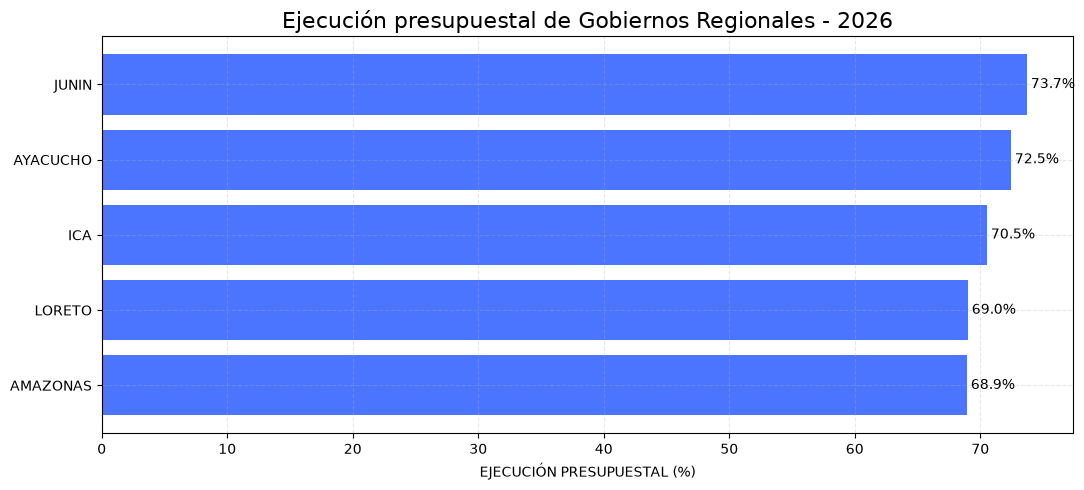

In [38]:
top_10 = regional.head(5).copy()

fig, ax = plt.subplots(figsize=(11,5))

ax.barh(top_10['DEPARTAMENTO_EJECUTORA_NOMBRE'],
        top_10['EJECUCION_%'], color='#4B75FF')

ax.invert_yaxis()

ax.set_xlabel('EJECUCIÓN PRESUPUESTAL (%)')
ax.set_title('Ejecución presupuestal de Gobiernos Regionales - 2026', fontsize = 16)
ax.grid(True, alpha=0.3)

for i, valor in enumerate(top_10['EJECUCION_%']):
    ax.text(valor + 0.3,
            i,
            f'{valor:.1f}%',
            va='center')

plt.tight_layout()
plt.show()

fig.savefig(
    "ranking_gobiernos_regionales.png",
    dpi=300,
    bbox_inches="tight"
)


In [39]:
df_junin = proyectos_regionales[proyectos_regionales['DEPARTAMENTO_EJECUTORA_NOMBRE'] == 'JUNIN']

In [40]:
tipo_gastos = df_junin.groupby(['DEPARTAMENTO_EJECUTORA_NOMBRE','ANO_EJE', 'FUNCION_NOMBRE'])[['MONTO_PIA',"MONTO_PIM", "MONTO_DEVENGADO"]].sum().reset_index()

tipo_gastos['EJECUCION_%'] = (tipo_gastos['MONTO_DEVENGADO'] / tipo_gastos['MONTO_PIM'])  * 100

tipo_gastos = tipo_gastos.sort_values(by='MONTO_DEVENGADO', ascending=False)
tipo_gastos.to_csv('tipo_gastos_junin.csv', index=False)
tipo_gastos

,DEPARTAMENTO_EJECUTORA_NOMBRE,ANO_EJE,FUNCION_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO,EJECUCION_%
4,JUNIN,2026,EDUCACION,376244594,370616254,3.014006e+08,81.324165
13,JUNIN,2026,TRANSPORTE,273364462,299047390,2.158416e+08,72.176377
0,JUNIN,2026,AGROPECUARIA,18479604,102481634,8.903914e+07,86.883023
11,JUNIN,2026,SALUD,186056903,152042859,8.283044e+07,54.478348
12,JUNIN,2026,SANEAMIENTO,19993268,41973929,3.144916e+07,74.925460
9,JUNIN,2026,"PLANEAMIENTO, GESTION Y RESERVA DE CONTINGENCIA",21335410,37785999,1.949692e+07,51.598267
7,JUNIN,2026,ORDEN PUBLICO Y SEGURIDAD,21202351,13152221,1.063115e+07,80.831616
10,JUNIN,2026,PROTECCION SOCIAL,6000000,6796062,5.987752e+06,88.106197
15,JUNIN,2026,VIVIENDA Y DESARROLLO URBANO,12286729,7942535,4.815524e+06,60.629560
3,JUNIN,2026,CULTURA Y DEPORTE,0,4824810,4.398554e+06,91.165322


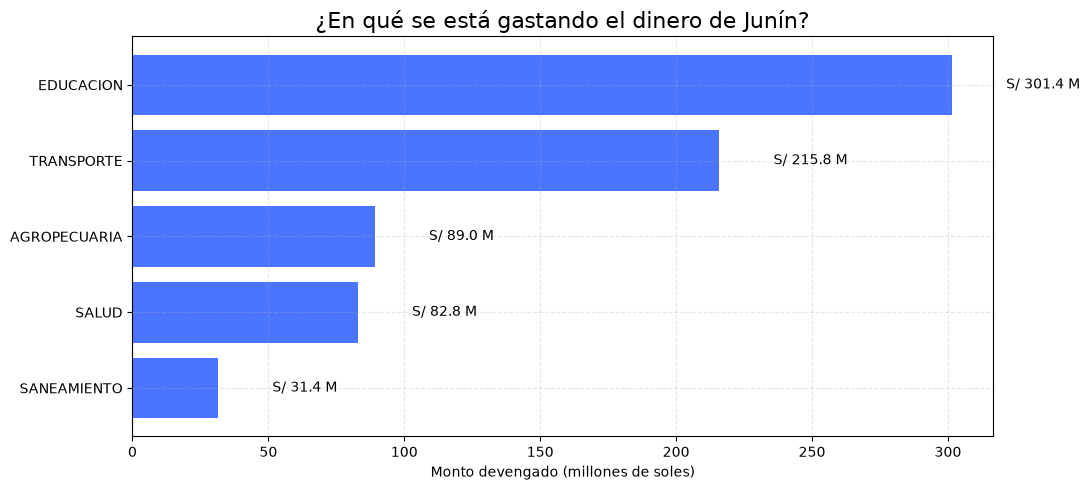

In [41]:
top_5 = tipo_gastos.head(5).copy()
top_5["DEVENGADO_M"] = top_5["MONTO_DEVENGADO"] / 1_000_000
top_5["PIM_M"] = top_5["MONTO_PIM"] / 1_000_000
top_5['RESTO'] = top_5['PIM_M'] - top_5['DEVENGADO_M']
top_5.to_csv('tipo_gastos_junin.csv', index=False)

fig, ax = plt.subplots(figsize=(11,5))

ax.barh(top_5['FUNCION_NOMBRE'],
        top_5['DEVENGADO_M'], color='#4B75FF')

ax.invert_yaxis()

ax.set_xlabel('Monto devengado (millones de soles)')
ax.set_title('¿En qué se está gastando el dinero de Junín?', fontsize = 16)
ax.grid(True, alpha=0.3)

for i, valor in enumerate(top_5["DEVENGADO_M"]):
    ax.text(
        valor + 20,
        i,
        f"S/ {valor:,.1f} M",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()